In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")


In [ ]:
# 1. Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. Reporta dimensiones, 
print("Dimensiones:", df.shape)

Dimensiones: (398, 9)


In [4]:
# Primeras filas
display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object


In [7]:
# Información general
print("\nInformación del dataset:")
df.info()


Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [8]:
#Clasificar las variables y decidir cuáles conviene tratar como categorías o como variable temporal.
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

¿Qué representa una fila?

Cada fila representa un automóvil y contiene información sobre su consumo de combustible (mpg), cilindros, cilindrada, potencia, peso, aceleración, año del modelo, origen y nombre.

In [9]:
# 2. Clasifica las variables "mpg", "cylinders", "displacement",
# "horsepower", "weight", "acceleration", "model_year", "origin"
# y "name" como cuantitativas o cualitativas;
# cuando corresponda, indica si son discretas/continuas
# o nominales/ordinales.
#
# Identifica qué variables, aunque puedan verse numéricas,
# conviene tratar como categorías o variables temporales.
#
# Pista de trabajo: El significado de una variable es más importante
# que su dtype.

clasificacion_variables = pd.DataFrame({
    "variable": [
        "mpg",
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model_year",
        "origin",
        "name"
    ],
    "clasificacion": [
        "numerica - continua",
        "numerica - discreta",
        "numerica - continua",
        "numerica - continua",
        "numerica - continua",
        "numerica - continua",
        "temporal - discreta",
        "categorica - nominal",
        "categorica - nominal"
    ]
})

clasificacion_variables

,variable,clasificacion
0,mpg,numerica - continua
1,cylinders,numerica - discreta
2,displacement,numerica - continua
3,horsepower,numerica - continua
4,weight,numerica - continua
5,acceleration,numerica - continua
6,model_year,temporal - discreta
7,origin,categorica - nominal
8,name,categorica - nominal


In [10]:
df.isna().sum()


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [4]:
# 3. Analiza valores faltantes y duplicados exactos.
# ¿En qué variable faltan datos y qué proporción representan?

# Valores faltantes
valores_faltantes = pd.DataFrame({
    "variable": df.columns,
    "cantidad_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() * 100).round(2)
})

valores_faltantes

,variable,cantidad_nulos,porcentaje_nulos
mpg,mpg,0,0.00
cylinders,cylinders,0,0.00
displacement,displacement,0,0.00
horsepower,horsepower,6,1.51
weight,weight,0,0.00
acceleration,acceleration,0,0.00
model_year,model_year,0,0.00
origin,origin,0,0.00
name,name,0,0.00


In [5]:
# Duplicados exactos

duplicados = df.duplicated().sum()

print("Cantidad de duplicados exactos:", duplicados)

Cantidad de duplicados exactos: 0


In [6]:
# 4. Estudia la cardinalidad de name.
# ¿Cuántos nombres distintos hay?
# ¿Que un nombre aparezca varias veces significa que las filas son duplicadas?
# Compruébalo con ejemplos.

# Cantidad de nombres distintos
cantidad_nombres = df["name"].nunique()

print("Cantidad de nombres distintos:", cantidad_nombres)

Cantidad de nombres distintos: 305


In [9]:
# Frecuencia de cada nombre

frecuencia_nombres = df["name"].value_counts()

frecuencia_nombres[frecuencia_nombres > 1].head(10)

name
ford pinto            6
ford maverick         5
amc matador           5
toyota corolla        5
chevrolet impala      4
amc hornet            4
peugeot 504           4
amc gremlin           4
toyota corona         4
chevrolet chevette    4
Name: count, dtype: int64

In [8]:
# Tomamos el primer nombre que aparece más de una vez

nombre_ejemplo = frecuencia_nombres[
    frecuencia_nombres > 1
].index[0]

display(df[df["name"] == nombre_ejemplo])

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
112,19.0,4,122.0,85.0,2310,18.5,73,usa,ford pinto
130,26.0,4,122.0,80.0,2451,16.5,74,usa,ford pinto
168,23.0,4,140.0,83.0,2639,17.0,75,usa,ford pinto
174,18.0,6,171.0,97.0,2984,14.5,75,usa,ford pinto
206,26.5,4,140.0,72.0,2565,13.6,76,usa,ford pinto


El dataset tiene 305 nombres de vehículos distintos. El nombre ford pinto aparece 6 veces, pero esto no significa que las filas sean duplicadas, ya que presentan diferentes valores en variables como mpg, displacement, horsepower, weight, acceleration y model_year. Por lo tanto, un mismo nombre puede aparecer en varios registros sin que estos sean duplicados exactos.

In [10]:
# 5. Calcula estadísticos descriptivos de mpg, weight y horsepower

variables = ["mpg", "weight", "horsepower"]

estadisticas = pd.DataFrame({
    "media": df[variables].mean(),
    "mediana": df[variables].median(),
    "desviacion_estandar": df[variables].std(),
    "Q1": df[variables].quantile(0.25),
    "Q3": df[variables].quantile(0.75)
})

estadisticas["IQR"] = estadisticas["Q3"] - estadisticas["Q1"]

estadisticas

,media,mediana,desviacion_estandar,Q1,Q3,IQR
mpg,23.514573,23.0,7.815984,17.50,29.0,11.50
weight,2970.424623,2803.5,846.841774,2223.75,3608.0,1384.25
horsepower,104.469388,93.5,38.491160,75.00,126.0,51.00


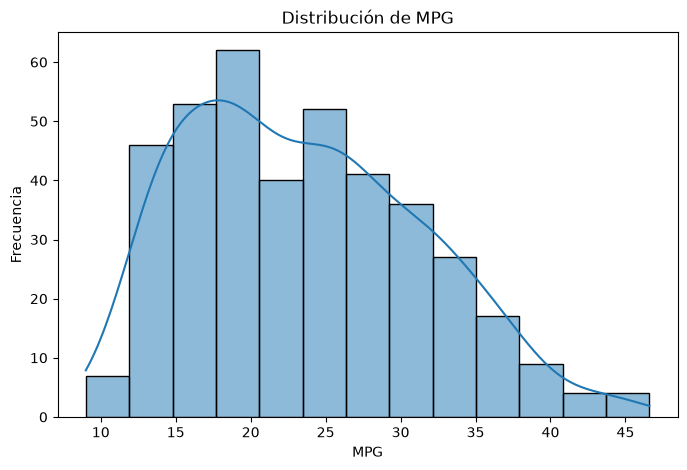

In [11]:
# 6. Analiza la distribución de mpg con histograma y KDE

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="mpg",
    kde=True
)

plt.title("Distribución de MPG")
plt.xlabel("MPG")
plt.ylabel("Frecuencia")

plt.show()

Interpretación: La distribución de mpg se concentra principalmente entre aproximadamente 15 y 30 MPG, con mayor frecuencia alrededor de 18–20 MPG. Presenta una asimetría hacia la derecha, debido a que la distribución se extiende hacia valores altos, llegando aproximadamente hasta 46 MPG.

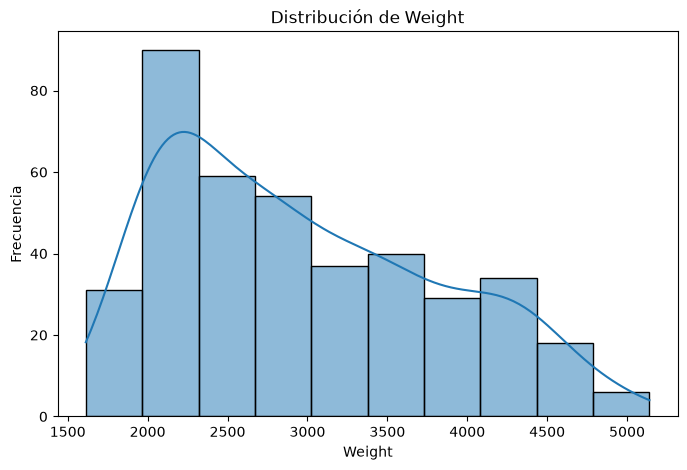

In [12]:
# 7. Analiza weight con histograma y boxplot

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="weight",
    kde=True
)

plt.title("Distribución de Weight")
plt.xlabel("Weight")
plt.ylabel("Frecuencia")

plt.show()

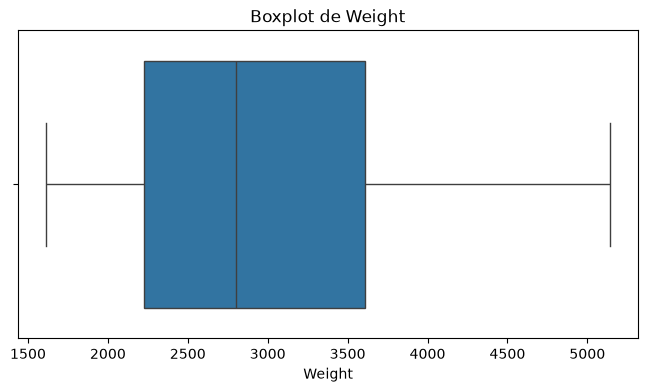

In [13]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="weight"
)

plt.title("Boxplot de Weight")
plt.xlabel("Weight")

plt.show()

In [14]:
Q1 = df["weight"].quantile(0.25)
Q3 = df["weight"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 2223.75
Q3: 3608.0
IQR: 1384.25
Límite inferior: 147.375
Límite superior: 5684.375


In [15]:
outliers_weight = df[
    (df["weight"] < limite_inferior) |
    (df["weight"] > limite_superior)
]

print("Cantidad de valores extremos:", len(outliers_weight))

display(outliers_weight[["name", "weight"]])

Cantidad de valores extremos: 0


,name,weight


La distribución de weight no es simétrica, presenta una asimetría hacia la derecha, debido a que se observa una mayor concentración de vehículos en pesos bajos y medios y una cola hacia los pesos más altos.

Según la regla del IQR, se obtuvo un Q1 de 2223.75, un Q3 de 3608.00 y un IQR de 1384.25. Los límites calculados fueron 147.375 y 5684.375. Como ningún vehículo se encuentra fuera de estos límites, no se identificaron valores extremos en weight mediante la regla del IQR.

In [16]:
# 8. Detecta outliers en horsepower usando 1.5 * IQR

Q1_hp = df["horsepower"].quantile(0.25)
Q3_hp = df["horsepower"].quantile(0.75)

IQR_hp = Q3_hp - Q1_hp

limite_inferior_hp = Q1_hp - 1.5 * IQR_hp
limite_superior_hp = Q3_hp + 1.5 * IQR_hp

print("Q1:", Q1_hp)
print("Q3:", Q3_hp)
print("IQR:", IQR_hp)
print("Límite inferior:", limite_inferior_hp)
print("Límite superior:", limite_superior_hp)

Q1: 75.0
Q3: 126.0
IQR: 51.0
Límite inferior: -1.5
Límite superior: 202.5


In [17]:
outliers_horsepower = df[
    (df["horsepower"] < limite_inferior_hp) |
    (df["horsepower"] > limite_superior_hp)
]

print("Cantidad de outliers:", len(outliers_horsepower))

display(
    outliers_horsepower[
        ["name", "horsepower", "mpg", "weight"]
    ]
)

Cantidad de outliers: 10


,name,horsepower,mpg,weight
6,chevrolet impala,220.0,14.0,4354
7,plymouth fury iii,215.0,14.0,4312
8,pontiac catalina,225.0,14.0,4425
13,buick estate wagon (sw),225.0,14.0,3086
25,ford f250,215.0,10.0,4615
27,dodge d200,210.0,11.0,4382
67,mercury marquis,208.0,11.0,4633
94,chrysler new yorker brougham,215.0,13.0,4735
95,buick electra 225 custom,225.0,12.0,4951
116,pontiac grand prix,230.0,16.0,4278


Se identificaron 10 valores extremos de horsepower, todos por encima del límite superior de 202.5 HP, con valores entre 208 y 230 HP. Estos valores no parecen errores evidentes, sino que corresponden a automóviles de alta potencia que resultan plausibles. Por lo tanto, aunque estadísticamente son outliers según la regla del IQR, no hay evidencia para considerarlos errores y no deberían eliminarse automáticamente.

In [18]:
# 9. Explora cylinders y origin mediante frecuencias y gráficos de barras

print("Frecuencia de cylinders:")
print(df["cylinders"].value_counts().sort_index())

Frecuencia de cylinders:
cylinders
3      4
4    204
5      3
6     84
8    103
Name: count, dtype: int64


In [19]:
print("\nFrecuencia de origin:")
print(df["origin"].value_counts())


Frecuencia de origin:
origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


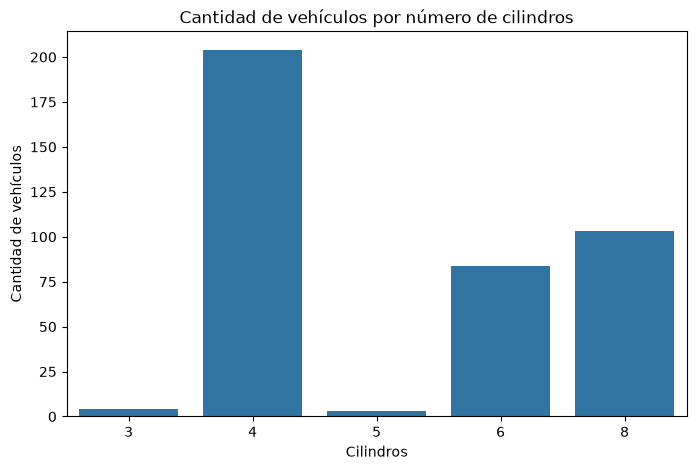

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="cylinders",
    order=sorted(df["cylinders"].unique())
)

plt.title("Cantidad de vehículos por número de cilindros")
plt.xlabel("Cilindros")
plt.ylabel("Cantidad de vehículos")

plt.show()

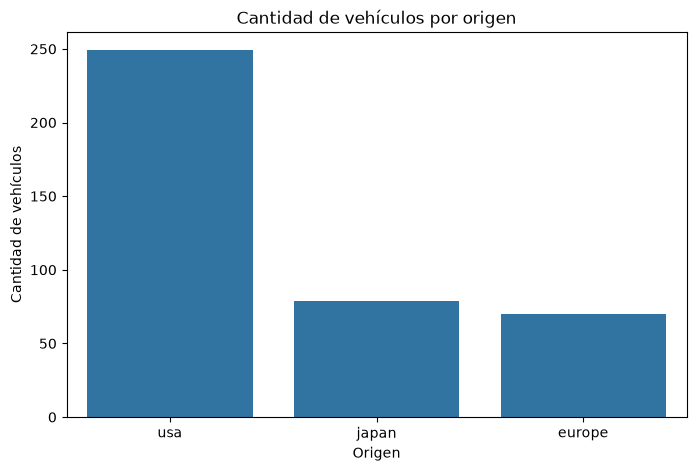

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="origin"
)

plt.title("Cantidad de vehículos por origen")
plt.xlabel("Origen")
plt.ylabel("Cantidad de vehículos")

plt.show()

In [22]:
# 10. Compara mpg entre vehículos con distinto número de cilindros

estadisticas_cilindros = df.groupby("cylinders")["mpg"].agg(
    ["count", "mean", "median"]
)

estadisticas_cilindros

,count,mean,median
cylinders,,,
3,4,20.550000,20.25
4,204,29.286765,28.25
5,3,27.366667,25.40
6,84,19.985714,19.00
8,103,14.963107,14.00


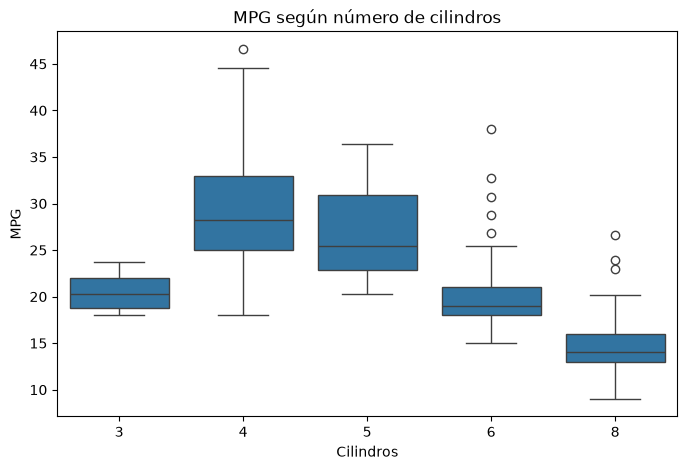

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="cylinders",
    y="mpg",
    order=sorted(df["cylinders"].unique())
)

plt.title("MPG según número de cilindros")
plt.xlabel("Cilindros")
plt.ylabel("MPG")

plt.show()

En general, a mayor número de cilindros, menor mpg. Los vehículos de 4 cilindros tienen el mayor promedio (29.29 MPG) y los de 8 cilindros el menor (14.96 MPG).

In [24]:
# 11. Compara mpg entre los tres orígenes

estadisticas_origin = df.groupby("origin")["mpg"].agg(
    ["count", "mean", "median"]
)

estadisticas_origin

,count,mean,median
origin,,,
europe,70,27.891429,26.5
japan,79,30.450633,31.6
usa,249,20.083534,18.5


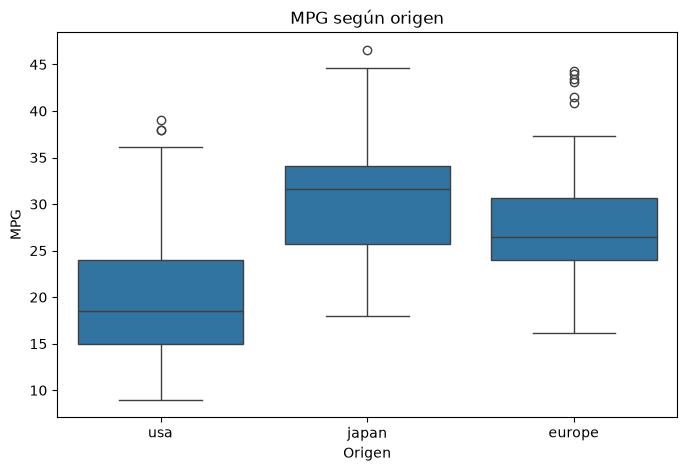

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="origin",
    y="mpg"
)

plt.title("MPG según origen")
plt.xlabel("Origen")
plt.ylabel("MPG")

plt.show()

Los vehículos de Japón presentan el mayor mpg promedio (30.45), seguidos por Europa (27.91) y USA (20.08). Por tanto, el rendimiento varía según el origen.

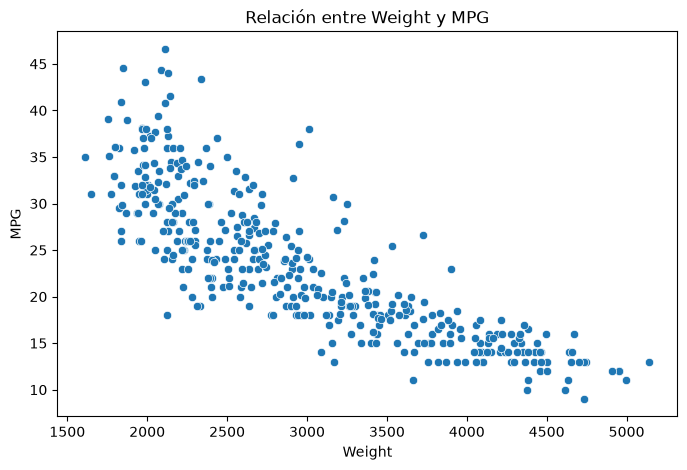

In [26]:
# 12. Estudia la relación entre weight y mpg

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg"
)

plt.title("Relación entre Weight y MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.show()

In [27]:
correlacion_weight_mpg = df["weight"].corr(df["mpg"])

print("Correlación Weight-MPG:", correlacion_weight_mpg)

Correlación Weight-MPG: -0.8317409332443354


Se observa una fuerte relación negativa entre weight y mpg: a medida que aumenta el peso del vehículo, tiende a disminuir su rendimiento de combustible. La correlación de −0.83 confirma esta relación.

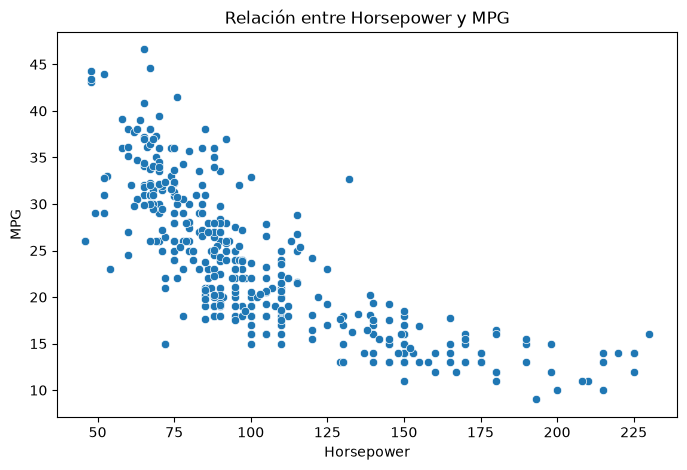

In [28]:
# 13. Estudia la relación entre horsepower y mpg

df_hp = df.dropna(subset=["horsepower"])

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_hp,
    x="horsepower",
    y="mpg"
)

plt.title("Relación entre Horsepower y MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.show()

In [29]:
correlacion_hp_mpg = df_hp["horsepower"].corr(df_hp["mpg"])
correlacion_weight_mpg = df["weight"].corr(df["mpg"])

print("Correlación Horsepower-MPG:", correlacion_hp_mpg)
print("Correlación Weight-MPG:", correlacion_weight_mpg)

Correlación Horsepower-MPG: -0.7784267838977761
Correlación Weight-MPG: -0.8317409332443354


: Existe una relación negativa fuerte entre horsepower y mpg (−0.78). Sin embargo, la relación entre weight y mpg es ligeramente más fuerte (−0.83). Por tanto, en este dataset el peso presenta una mayor asociación lineal con mpg que la potencia.

In [30]:
# 14. Construye una matriz de correlación y heatmap

df_numerico = df.select_dtypes(include="number")

matriz_correlacion = df_numerico.corr()

matriz_correlacion

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


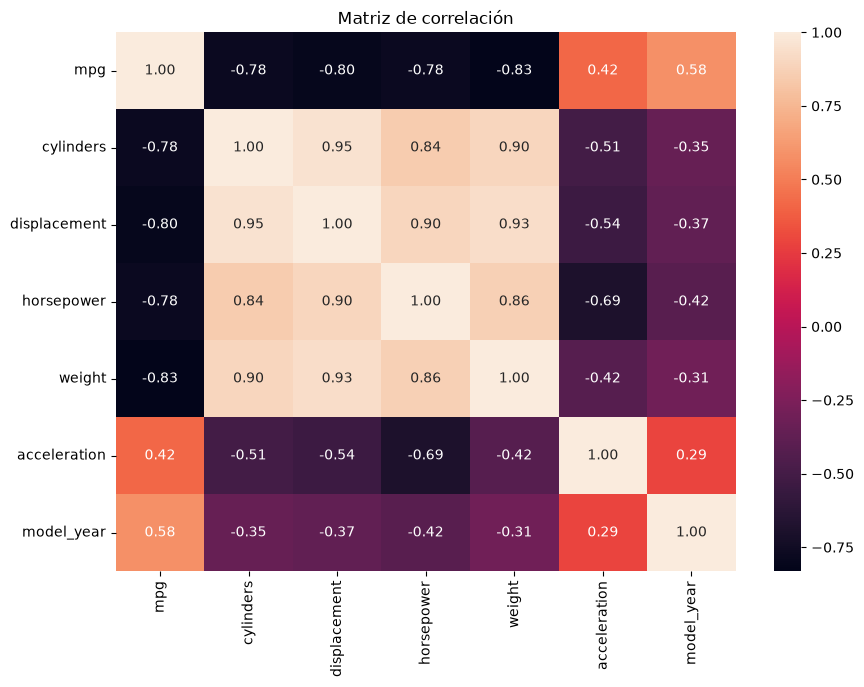

In [31]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

In [32]:
correlacion_mpg = matriz_correlacion["mpg"].drop("mpg")

top_3 = correlacion_mpg.abs().sort_values(
    ascending=False
).head(3)

top_3

weight          0.831741
displacement    0.804203
horsepower      0.778427
Name: mpg, dtype: float64

In [33]:
matriz_correlacion

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


Las variables con mayor asociación lineal con mpg son weight, displacement y horsepower. Además, cylinders, displacement y weight presentan correlaciones muy altas entre sí, lo que indica posible redundancia o multicolinealidad entre estos predictores.

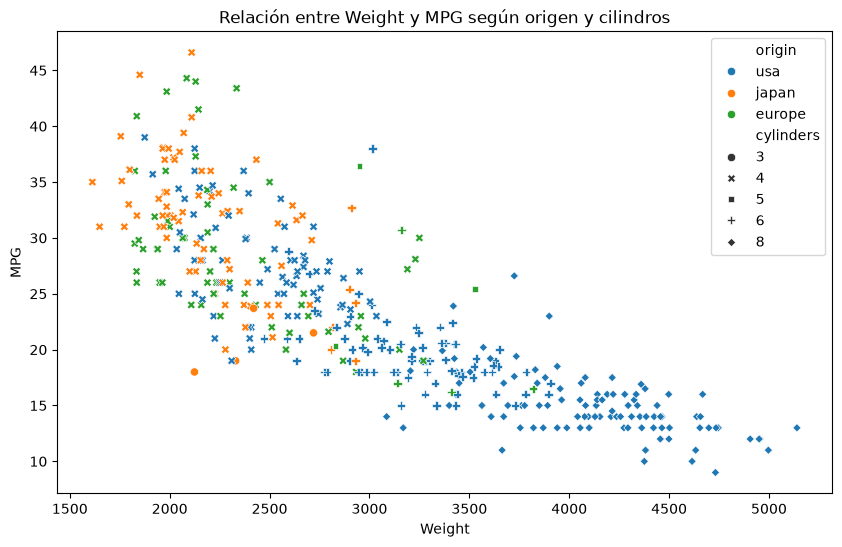

In [34]:
# 15. Análisis multivariado de weight frente a mpg

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg",
    hue="origin",
    style="cylinders"
)

plt.title("Relación entre Weight y MPG según origen y cilindros")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.show()

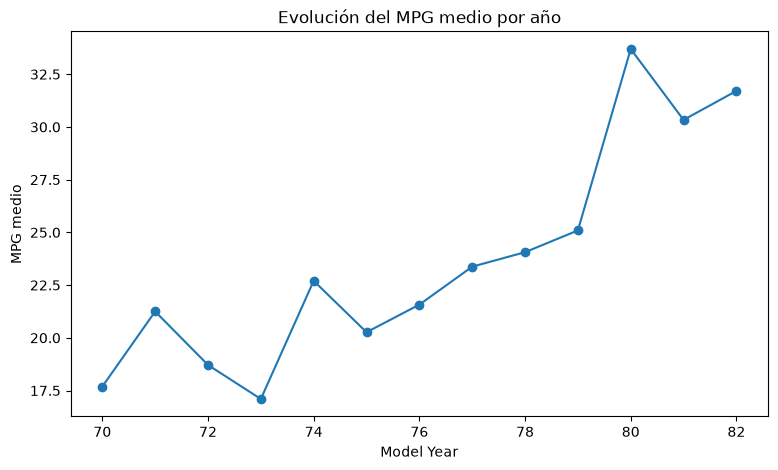

In [35]:
mpg_año = df.groupby("model_year")["mpg"].mean()

plt.figure(figsize=(9, 5))

plt.plot(
    mpg_año.index,
    mpg_año.values,
    marker="o"
)

plt.title("Evolución del MPG medio por año")
plt.xlabel("Model Year")
plt.ylabel("MPG medio")

plt.show()

Se mantiene una relación negativa entre weight y mpg: los vehículos más pesados tienden a presentar menor mpg. Además, el mpg medio muestra una tendencia general creciente con el paso de los años, aunque presenta algunas variaciones entre años.

In [36]:
# 16. Analiza la evolución de mpg por model_year

mpg_por_año = df.groupby("model_year")["mpg"].agg(
    ["mean", "median"]
)

mpg_por_año

,mean,median
model_year,,
70,17.689655,16.00
71,21.250000,19.00
72,18.714286,18.50
73,17.100000,16.00
74,22.703704,24.00
75,20.266667,19.50
76,21.573529,21.00
77,23.375000,21.75
78,24.061111,20.70


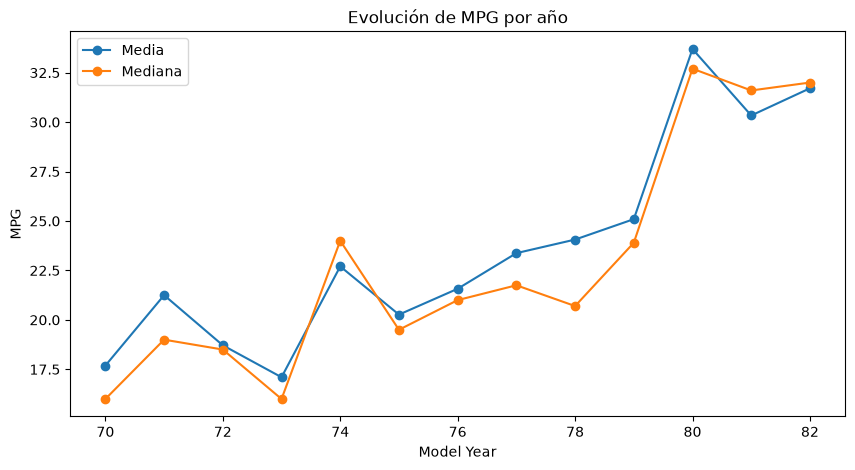

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    mpg_por_año.index,
    mpg_por_año["mean"],
    marker="o",
    label="Media"
)

plt.plot(
    mpg_por_año.index,
    mpg_por_año["median"],
    marker="o",
    label="Mediana"
)

plt.title("Evolución de MPG por año")
plt.xlabel("Model Year")
plt.ylabel("MPG")
plt.legend()

plt.show()

El mpg presenta una tendencia general creciente a lo largo de los años, aunque con algunas variaciones. El mayor incremento se observa alrededor del año 80, alcanzando aproximadamente 33 MPG

In [38]:
# 17. Compara el weight de los automóviles por origin

estadisticas_weight_origin = df.groupby("origin")["weight"].agg(
    ["count", "mean", "median"]
)

estadisticas_weight_origin

,count,mean,median
origin,,,
europe,70,2423.300000,2240.0
japan,79,2221.227848,2155.0
usa,249,3361.931727,3365.0


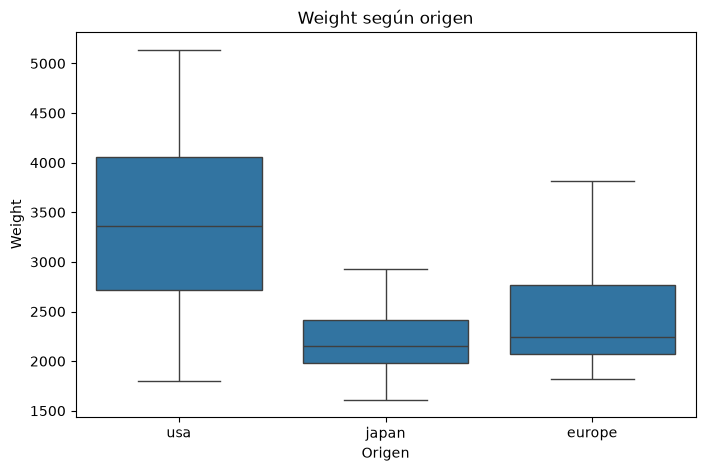

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="origin",
    y="weight"
)

plt.title("Weight según origen")
plt.xlabel("Origen")
plt.ylabel("Weight")

plt.show()

Los vehículos de USA son considerablemente más pesados que los de Japón y Europa. Esto puede ayudar a explicar su menor mpg, ya que existe una relación negativa entre el peso y el rendimiento.

In [40]:
# 18. Estudia el patrón de los valores faltantes de horsepower

faltantes_hp = df[df["horsepower"].isna()]

display(
    faltantes_hp[
        ["horsepower", "origin", "cylinders", "model_year", "name"]
    ]
)

,horsepower,origin,cylinders,model_year,name
32,NaN,usa,4,71,ford pinto
126,NaN,usa,6,74,ford maverick
330,NaN,europe,4,80,renault lecar deluxe
336,NaN,usa,4,80,ford mustang cobra
354,NaN,europe,4,81,renault 18i
374,NaN,usa,4,82,amc concord dl


In [41]:
print("Faltantes por origin:")
print(faltantes_hp["origin"].value_counts())

print("\nFaltantes por cylinders:")
print(faltantes_hp["cylinders"].value_counts())

print("\nFaltantes por model_year:")
print(faltantes_hp["model_year"].value_counts())

Faltantes por origin:
origin
usa       4
europe    2
Name: count, dtype: int64

Faltantes por cylinders:
cylinders
4    5
6    1
Name: count, dtype: int64

Faltantes por model_year:
model_year
80    2
71    1
74    1
81    1
82    1
Name: count, dtype: int64


Los 6 valores faltantes de horsepower se concentran principalmente en vehículos de USA (4) y de 4 cilindros (5). Por año, están distribuidos entre 1971 y 1982, con mayor frecuencia en 1980 (2 casos). Al ser pocos casos, este patrón debe describirse sin establecer conclusiones fuertes.

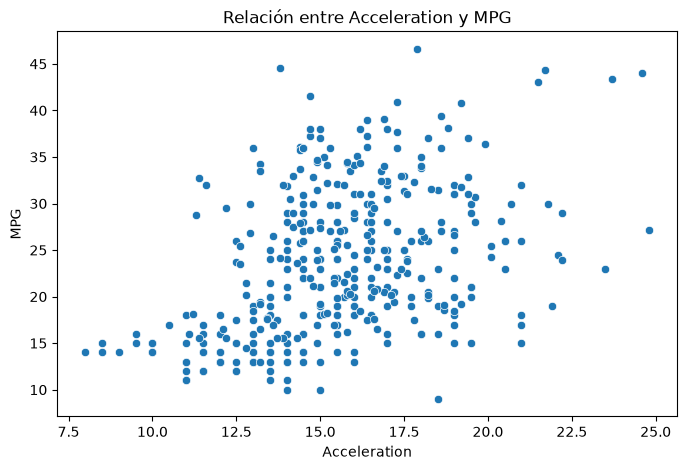

In [42]:
# 19. Relación entre acceleration y mpg

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="acceleration",
    y="mpg"
)

plt.title("Relación entre Acceleration y MPG")
plt.xlabel("Acceleration")
plt.ylabel("MPG")

plt.show()

In [43]:
correlacion_acc_mpg = df["acceleration"].corr(df["mpg"])
correlacion_weight_mpg = df["weight"].corr(df["mpg"])
correlacion_hp_mpg = df["horsepower"].corr(df["mpg"])

print("Correlación Acceleration-MPG:", correlacion_acc_mpg)
print("Correlación Weight-MPG:", correlacion_weight_mpg)
print("Correlación Horsepower-MPG:", correlacion_hp_mpg)

Correlación Acceleration-MPG: 0.42028891210165065
Correlación Weight-MPG: -0.8317409332443354
Correlación Horsepower-MPG: -0.7784267838977761


Acceleration presenta una relación positiva moderada con mpg (0.42), pero es más débil que las relaciones de weight (−0.83) y horsepower (−0.78) con mpg.

In [44]:
# 20. Relación entre displacement, horsepower y weight

variables = ["displacement", "horsepower", "weight"]

correlaciones = df[variables].corr()

correlaciones

,displacement,horsepower,weight
displacement,1.000000,0.897257,0.932824
horsepower,0.897257,1.000000,0.864538
weight,0.932824,0.864538,1.000000


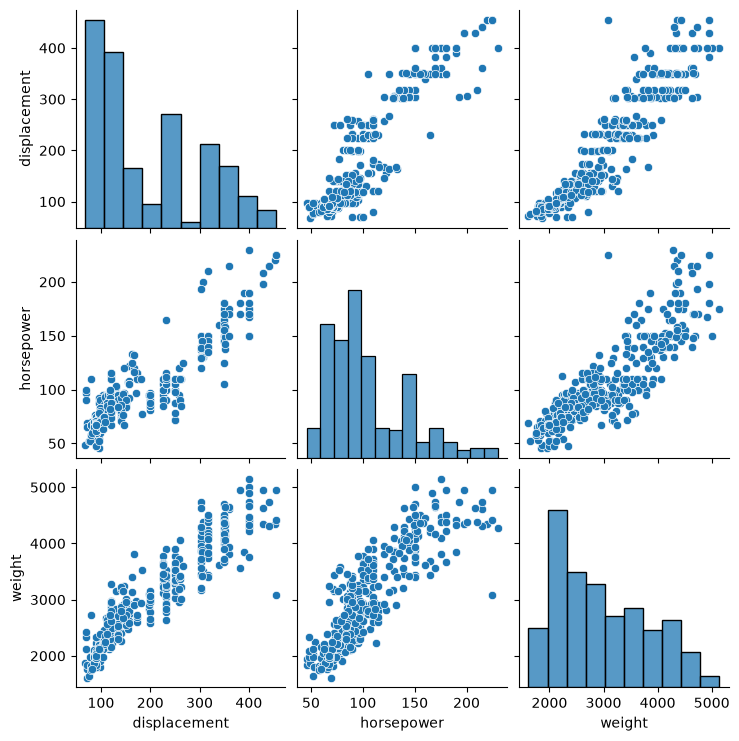

In [45]:
sns.pairplot(
    df[variables].dropna()
)

plt.show()

Las tres variables presentan correlaciones positivas muy altas, por lo que contienen información similar. Si se usan juntas como predictores puede aparecer multicolinealidad o redundancia, dificultando la interpretación de un modelo.

In [46]:
# 21. Tabla pivote de mpg por cylinders y origin

tabla_pivote = df.pivot_table(
    index="cylinders",
    columns="origin",
    values="mpg",
    aggfunc=["mean", "count"]
)

tabla_pivote

mean                        count             
origin        europe      japan        usa europe japan    usa
cylinders                                                     
3                NaN  20.550000        NaN    NaN   4.0    NaN
4          28.411111  31.595652  27.840278   63.0  69.0   72.0
5          27.366667        NaN        NaN    3.0   NaN    NaN
6          20.100000  23.883333  19.663514    4.0   6.0   74.0
8                NaN        NaN  14.963107    NaN   NaN  103.0

En general, el mpg disminuye al aumentar el número de cilindros dentro de cada origen. Sin embargo, algunos grupos tienen muy pocos vehículos, como 3 cilindros en Japón (4) y 5 cilindros en Europa (3), por lo que sus medias deben interpretarse con cautela.

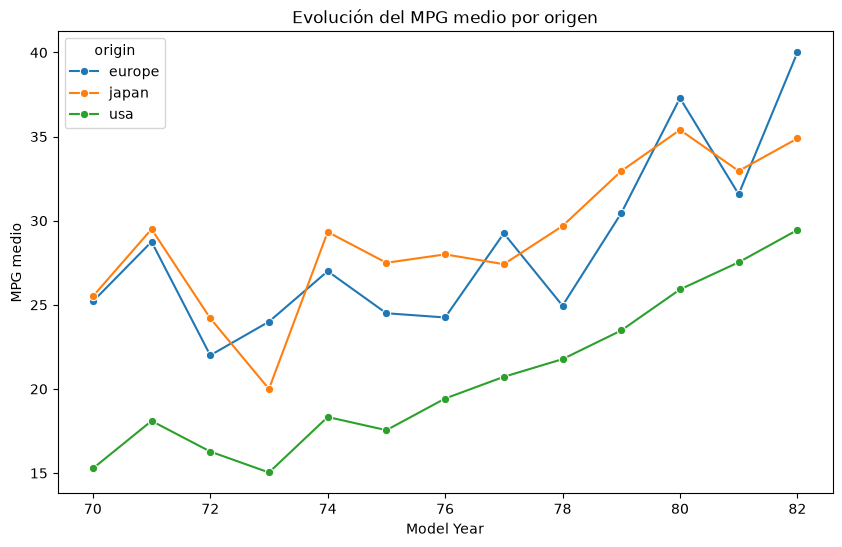

In [47]:
# 22. Evolución de MPG por origen

mpg_origin_año = df.groupby(
    ["model_year", "origin"]
)["mpg"].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=mpg_origin_año,
    x="model_year",
    y="mpg",
    hue="origin",
    marker="o"
)

plt.title("Evolución del MPG medio por origen")
plt.xlabel("Model Year")
plt.ylabel("MPG medio")

plt.show()

Los tres orígenes muestran una tendencia general de mejora del mpg con los años. Japón y Europa mantienen valores superiores a USA durante gran parte del periodo, por lo que la brecha entre orígenes no permanece constante.

In [48]:
# 23. Comparar outliers de horsepower con IQR y Z-score

hp = df["horsepower"].dropna()

# Método IQR
Q1 = hp.quantile(0.25)
Q3 = hp.quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df[
    (df["horsepower"] > limite_superior)
].copy()

# Método Z-score
media_hp = hp.mean()
desv_hp = hp.std()

df["z_horsepower"] = (df["horsepower"] - media_hp) / desv_hp

outliers_z = df[
    df["z_horsepower"].abs() > 3
].copy()

print("Outliers por IQR:", len(outliers_iqr))
print("Outliers por Z-score:", len(outliers_z))

print("\nVehículos por IQR:")-
display(outliers_iqr[["name", "horsepower", "mpg", "weight"]])

print("\nVehículos por Z-score:")
display(outliers_z[["name", "horsepower", "mpg", "weight"]])

Outliers por IQR: 10
Outliers por Z-score: 5

Vehículos por IQR:


,name,horsepower,mpg,weight
6,chevrolet impala,220.0,14.0,4354
7,plymouth fury iii,215.0,14.0,4312
8,pontiac catalina,225.0,14.0,4425
13,buick estate wagon (sw),225.0,14.0,3086
25,ford f250,215.0,10.0,4615
27,dodge d200,210.0,11.0,4382
67,mercury marquis,208.0,11.0,4633
94,chrysler new yorker brougham,215.0,13.0,4735
95,buick electra 225 custom,225.0,12.0,4951
116,pontiac grand prix,230.0,16.0,4278



Vehículos por Z-score:


,name,horsepower,mpg,weight
6,chevrolet impala,220.0,14.0,4354
8,pontiac catalina,225.0,14.0,4425
13,buick estate wagon (sw),225.0,14.0,3086
95,buick electra 225 custom,225.0,12.0,4951
116,pontiac grand prix,230.0,16.0,4278


In [49]:
# Vehículos detectados por ambos métodos

coinciden = set(outliers_iqr["name"]) & set(outliers_z["name"])

print("Outliers detectados por ambos métodos:", len(coinciden))
print(coinciden)

Outliers detectados por ambos métodos: 5
{'chevrolet impala', 'buick electra 225 custom', 'pontiac grand prix', 'buick estate wagon (sw)', 'pontiac catalina'}


El método IQR detecta 10 outliers, mientras que el Z-score detecta 5. Los 5 casos del Z-score también están incluidos en el IQR. El IQR identifica más valores porque es menos sensible a la asimetría de la distribución.

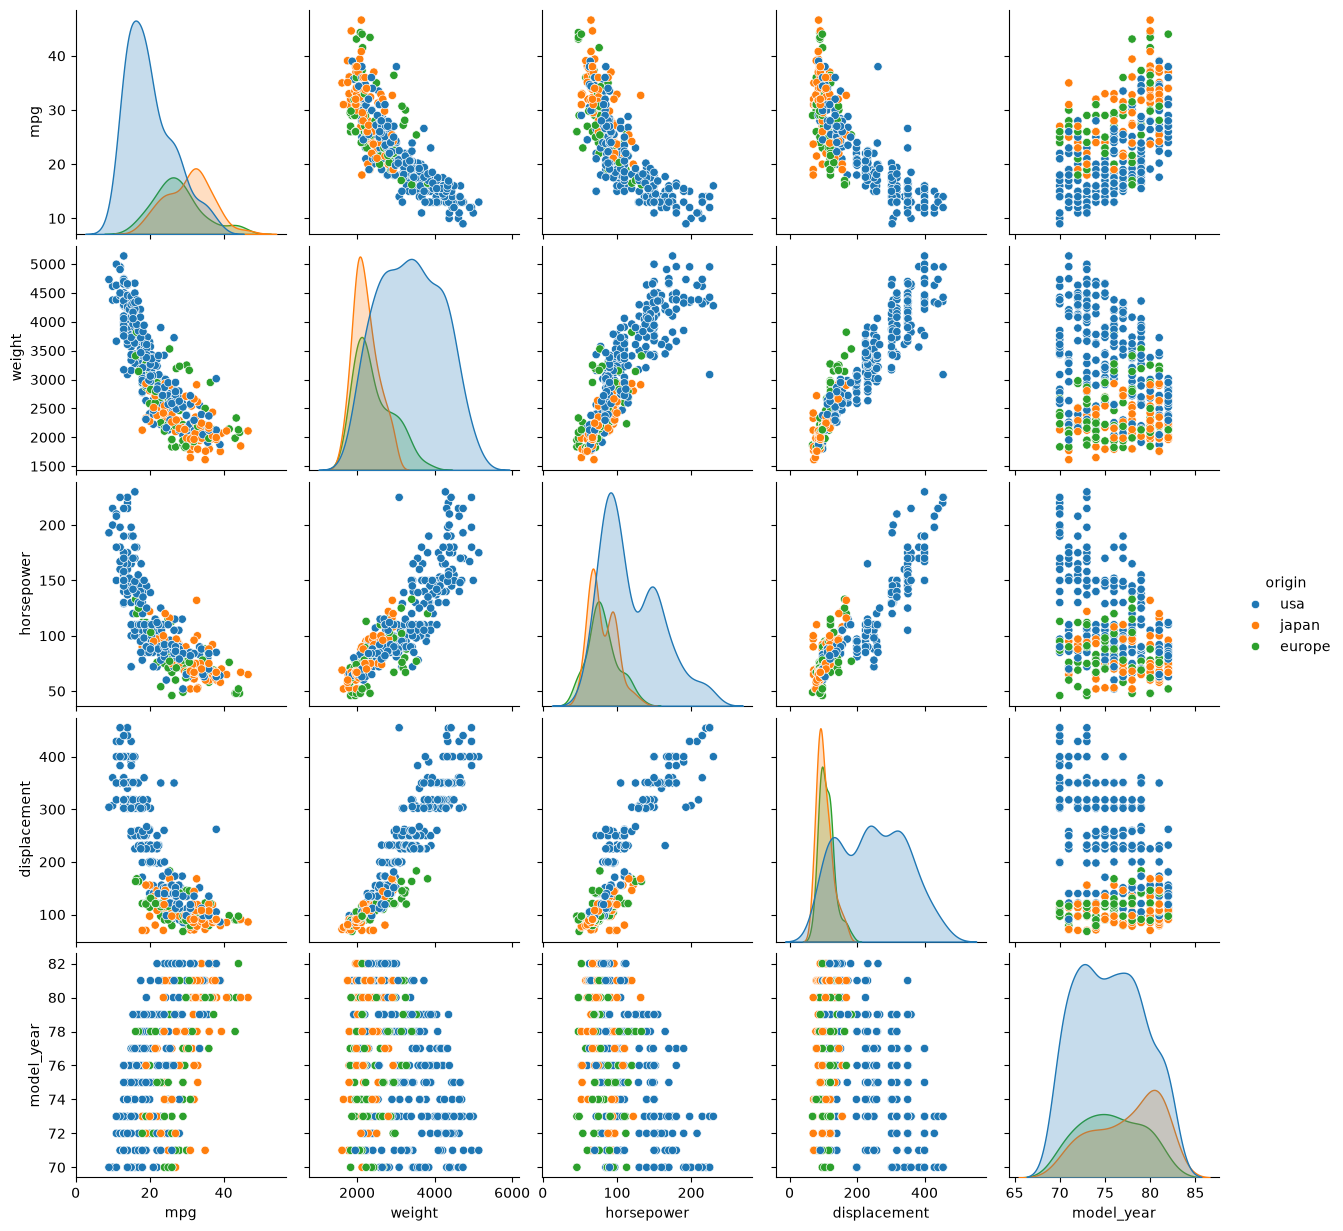

In [50]:
# 24. Pairplot de las principales variables numéricas

variables_pairplot = [
    "mpg",
    "weight",
    "horsepower",
    "displacement",
    "model_year"
]

sns.pairplot(
    df[variables_pairplot + ["origin"]].dropna(),
    hue="origin"
)

plt.show()

Se observa una relación negativa entre mpg y las variables weight, horsepower y displacement. Además, los vehículos de USA tienden a ser más pesados y presentar menor mpg, mientras que Japón y Europa muestran valores generalmente más altos de mpg.

In [5]:
# 25. Elabora un “registro de decisiones” para preparar un análisis posterior:
# decide qué harías con los nulos de `horsepower`, `name`, `origin`,
# los outliers de potencia y las variables altamente correlacionadas.
#
# Pista de trabajo: Distingue entre decisiones para EDA y decisiones para modelado;
# una variable útil para interpretar puede no ser adecuada como predictor directo.

registro_decisiones = pd.DataFrame({
    'Elemento': [
        'Nulos horsepower',
        'Outliers horsepower',
        'Variables colineales',
        'Variable origin',
        'Variable name'
    ],
    
    'Decisión EDA': [
        'Conservar/omitir en pares',
        'Mantener para contexto',
        'Usar todas para entender el auto',
        'Mapear etiquetas (USA/EU/JP)',
        'Analizar marcas frecuentes'
    ],
    
    'Decisión Modelado': [
        'Imputar por mediana de cilindros',
        'Mantener y evaluar su influencia; considerar transformación si fuera necesario',
        'Seleccionar solo peso o usar PCA',
        'Aplicar One-Hot Encoding',
        'Extraer marca o descartar'
    ]
})

registro_decisiones

,Elemento,Decisión EDA,Decisión Modelado
0,Nulos horsepower,Conservar/omitir en pares,Imputar por mediana de cilindros
1,Outliers horsepower,Mantener para contexto,Mantener y evaluar su influencia; considerar t...
2,Variables colineales,Usar todas para entender el auto,Seleccionar solo peso o usar PCA
3,Variable origin,Mapear etiquetas (USA/EU/JP),Aplicar One-Hot Encoding
4,Variable name,Analizar marcas frecuentes,Extraer marca o descartar
